## Projeto Sprint 8 - Análise de Negócio

### Contexto do Projeto
Trabalhamos no departamento analítico da Y.Afisha e fomos encarregados de otimizar os investimentos em marketing da empresa. Para isso, precisamos entender melhor o perfil dos consumidores e a eficiência dos diferentes canais de aquisição.

### Objetivo
Analisar os dados de janeiro de 2017 a dezembro de 2018 para otimizar os gastos com marketing e maximizar o retorno sobre investimento (ROI).

### Perguntas de Negócio
Este projeto busca responder às seguintes questões estratégicas:
* Qual é o perfil do nosso consumidor?
* Por quais canais de marketing nossos clientes chegam até nós?
* Quando os usuários começam a fazer compras após o primeiro acesso?
* Qual é o retorno sobre investimento (ROI) dos nossos canais de marketing?
* Quanto tempo demora para recuperar o investimento em aquisição de clientes?
* Qual canal oferece o melhor custo-benefício para futuros investimentos?

In [1]:
# Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [2]:
#Importando os dados de visitas(visits) já com a conversão nas colunas referentes a Start Ts e End Ts (object -> datetime).
# Convertendo a coluna Device para 'category' visto que só temos 2 categorias (Touch e Desktop) para que futuramente possa ser utilizada de forma mais eficiente.
#Além disso, convertendo os nomes das colunas para letras minúsculas para facilitar a manipulação dos dados.
visits = pd.read_csv('visits_log_us.csv', 
                     parse_dates=['Start Ts', 'End Ts'], 
                     dtype={'Device': 'category'})
visits.columns = visits.columns.str.lower()

In [3]:
#importando os dados de pedidos (order) já com a conversão na coluna Buy Ts (object -> datetime).
#Convertendo os nomes das colunas para letras minúsculas para facilitar a manipulação dos dados.
orders = pd.read_csv('orders_log_us.csv',
                     parse_dates=['Buy Ts'])
orders.columns = orders.columns.str.lower()

In [4]:
#Importando os dados de custos(costs) já com a conversão na coluna Dt de (object -> datetime).
#Convertendo os nomes das colunas para letras minúsculas para facilitar a manipulação dos dados.
costs = pd.read_csv('costs_us.csv',
                     parse_dates=['dt'])
costs.columns = costs.columns.str.lower()

## Análisando os DataFrames 

In [5]:
#Analisando os dados de visitas.
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end ts     359400 non-null  datetime64[ns]
 2   source id  359400 non-null  int64         
 3   start ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB


In [6]:
#Observando os dados de visitas(visits).
visits.head()

,device,end ts,source id,start ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [7]:
#Analisando os dados de pedidos(order).
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [8]:
#Observando os dados de vendas(order).
orders.head()

,buy ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [9]:
#Analisando os dados de custos(costs).
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


### Análisando Métrica - Produto

In [11]:
#Criando as colunas de data, semana e mês para a tabela de visitas para facilitar a análise dos dados.
visits['date'] = visits['start ts'].dt.date
visits['week'] = visits['start ts'].dt.isocalendar().week
visits['month'] = visits['start ts'].dt.to_period('M')    

In [12]:
#Usuários únicos por dia, semana e mês.
dau = visits.groupby('date')['uid'].nunique().mean()
mau = visits.groupby('month')['uid'].nunique().mean()
wau = visits.groupby('week')['uid'].nunique().mean()

#Exibindo os resultados de DAU, MAU e WAU.
print(f'DAU médio: {dau:.2f}')
print(f'WAU médio: {wau:.2f}')
print(f'MAU médio: {mau:.2f}')

DAU médio: 907.99
WAU médio: 5825.29
MAU médio: 23228.42


In [13]:
#Analisando os dispositivos utilizados para acessar o site.
device_counts = visits.groupby('device').agg({'uid':'count'}).reset_index()
device_counts.head()

,device,uid
0,desktop,262567
1,touch,96833


In [14]:
#Contando quantas pessoas acessam o site cada dia, semana e mês.
unique_users_per_day = visits.groupby(['date','device']).agg({'uid':['nunique','count']}).reset_index()
unique_users_per_week = visits.groupby(['week','device']).agg({'uid':['nunique','count']}).reset_index()
unique_users_per_month = visits.groupby(['month','device']).agg({'uid':['nunique','count']}).reset_index()

#Renomeando as colunas para facilitar a manipulação dos dados.
unique_users_per_day.columns = ['date', 'device', 'unique_users', 'total_visits']
unique_users_per_week.columns = ['week', 'device', 'unique_users', 'total_visits']
unique_users_per_month.columns = ['month', 'device', 'unique_users', 'total_visits']    


#Calculando a taxa de retorno por dia, semana e mês para cada dispositivo.
conversion_rate_per_day = unique_users_per_day.copy()   
conversion_rate_per_day['conversion_rate'] = conversion_rate_per_day['unique_users'] / conversion_rate_per_day['total_visits']  
conversion_rate_per_week = unique_users_per_week.copy()
conversion_rate_per_week['conversion_rate'] = conversion_rate_per_week['unique_users'] / conversion_rate_per_week['total_visits']
conversion_rate_per_month = unique_users_per_month.copy()   
conversion_rate_per_month['conversion_rate'] = conversion_rate_per_month['unique_users'] / conversion_rate_per_month['total_visits']
#Exibindo as taxas de retorno por dia, semana e mês para cada dispositivo.
print("Taxa de retorno por dia e dispositivo:")
print(conversion_rate_per_day.head())
print("\nTaxa de retorno por semana e dispositivo:")
print(conversion_rate_per_week.head())
print("\nTaxa de retorno por mês e dispositivo:")
print(conversion_rate_per_month.head())



Taxa de retorno por dia e dispositivo:
         date   device  unique_users  total_visits  conversion_rate
0  2017-06-01  desktop           455           501         0.908184
1  2017-06-01    touch           153           163         0.938650
2  2017-06-02  desktop           458           498         0.919679
3  2017-06-02    touch           152           160         0.950000
4  2017-06-03  desktop           307           329         0.933131

Taxa de retorno por semana e dispositivo:
   week   device  unique_users  total_visits  conversion_rate
0     1  desktop          4250          4997         0.850510
1     1    touch          2716          3060         0.887582
2     2  desktop          4875          5771         0.844741
3     2    touch          1883          2100         0.896667
4     3  desktop          5128          6224         0.823907

Taxa de retorno por mês e dispositivo:
     month   device  unique_users  total_visits  conversion_rate
0  2017-06  desktop          9761

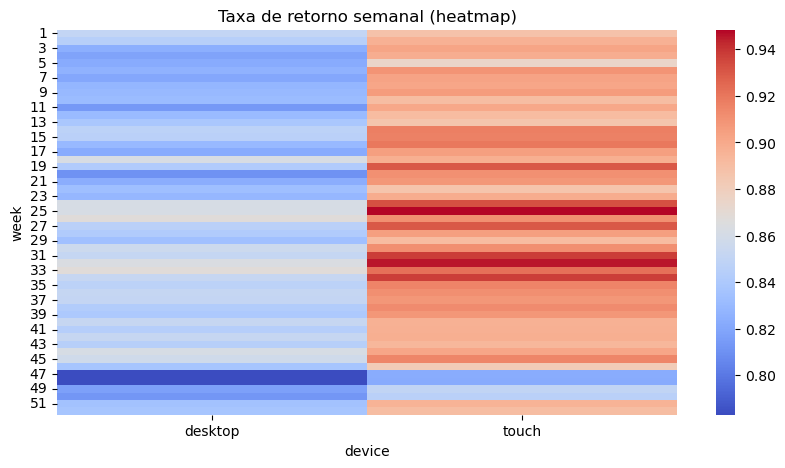

In [15]:
#Visualizando a taxa de retorno por semana
pivot = conversion_rate_per_week.pivot_table(
    index='week',
    columns='device',
    values='conversion_rate'
)
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Taxa de retorno semanal (heatmap)')
plt.show()


Observa-se que o dispositivo touch retém proporcionalmente mais usuários de semana para semana do que o desktop, porém com uma variação significativamente maior. Isso sugere que os usuários mobile apresentam um comportamento de uso mais irregular, alternando entre períodos de alta atividade e períodos de ausência. Já os usuários de desktop apresentam um padrão mais estável e previsível, embora com uma taxa de retenção menor.

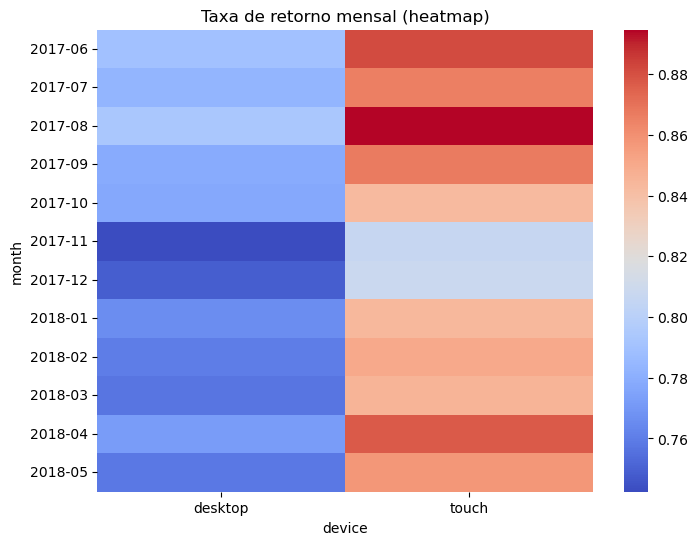

In [16]:
#Visualizando a taxa de retorno por dia
pivot = conversion_rate_per_month.pivot_table(
    index='month',
    columns='device',
    values='conversion_rate'
)
plt.figure(figsize=(8,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Taxa de retorno mensal (heatmap)')
plt.show()

A queda observada em novembro de 2017 no desktop provavelmente reflete um efeito de diluição: um grande volume de novos usuários entrou no período, possivelmente impulsionado por um aumento de investimento em marketing, mas uma parte significativa não foi retida. Esse padrão indica um alerta clássico em produto: crescimento baseado apenas em aquisição, sem melhoria na retenção, tende a ser caro e insustentável no longo prazo.

In [17]:
#Calculando o tempo médio gasto no site por cada dispositivo.
visits['duration'] = (visits['end ts'] - visits['start ts']).dt.total_seconds() / 60  # Convertendo a duração para minutos
average_duration_per_device = visits.groupby('device')['duration'].mean()
average_duration_per_device.columns = ['device', 'average_duration_minutes']
print("Tempo médio gasto no site por cada dispositivo (em minutos):")
print(average_duration_per_device.round(2))  

Tempo médio gasto no site por cada dispositivo (em minutos):
device
desktop    11.72
touch       7.99
Name: duration, dtype: float64


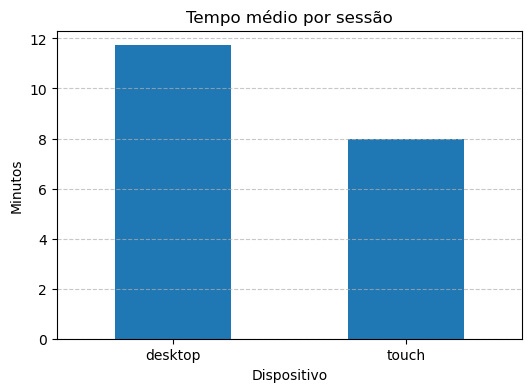

In [18]:
#Visualizando o tempo médio gasto no site por cada dispositivo.
average_duration_per_device.plot(kind='bar', figsize=(6,4))
plt.title('Tempo médio por sessão')
plt.ylabel('Minutos')
plt.xlabel('Dispositivo')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
#Frequencia que os usuarios voltam ao site.
#Data da primeira visita de cada usuário e dispositivo
first_visit = visits.groupby(['uid'])['date'].min().reset_index()
first_visit.columns = ['uid','first_date']

#Juntar ao log completo de visitas
visits = visits.merge(first_visit, on=['uid'], how='left')

# Passo 3: calcular dias desde a 1ª visita
visits['days_since_first'] = (
    pd.to_datetime(visits['date']) - pd.to_datetime(visits['first_date'])
).dt.days

# Contar usuários que voltaram em cada janela
total = visits['uid'].nunique()
ret_1d  = visits[visits['days_since_first'] == 1]['uid'].nunique()
ret_7d  = visits[(visits['days_since_first'] > 0) & 
                  (visits['days_since_first'] <= 7)]['uid'].nunique()
ret_30d = visits[(visits['days_since_first'] > 0) & 
                  (visits['days_since_first'] <= 30)]['uid'].nunique()

print(f"Dia 1: {ret_1d/total*100:.1f}% | 7d: {ret_7d/total*100:.1f}% | 30d: {ret_30d/total*100:.1f}%")


Dia 1: 2.6% | 7d: 6.4% | 30d: 11.0%


Com base na análise inicial do site de venda de ingressos, observamos uma média de 907 usuários ativos por dia, 5.825 por semana e 23.228 por mês. O volume de usuários cresceu cerca de 3 vezes entre junho e novembro de 2017, atingindo o pico no período, mas desacelerou gradualmente ao longo de 2018. O desktop concentra 73% dos acessos e também apresenta maior engajamento: a duração mediana das sessões é de 6 minutos, contra 3 minutos no touch. Apesar disso, proporcionalmente, usuários touch retornam mais ao site.No geral, a retenção é baixa: apenas 2,6% dos usuários retornam após 1 dia, 6,4% após 7 dias e 11% após 30 dias, indicando um comportamento de uso mais pontual do que recorrente.

### Análise Métrica - Pedidos

In [ ]:
#Calculando o tempo entre a primeira visita e a primeira compra.
# Primeira compra de cada usuário
first_order = orders.groupby('uid')['buy ts'].min().reset_index()
first_order.columns = ['uid', 'first_order_ts']

#Juntar pelos usuários que compraram
merged = first_order.merge(first_visit, on='uid', how='left')

# Converter as colunas para datetime
merged['first_order_ts'] = pd.to_datetime(merged['first_order_ts'])
merged['first_date'] = pd.to_datetime(merged['first_date'])

# Diferença em dias entre a primeira compra e a primeira visita
merged['days_to_buy'] = (
    merged['first_order_ts'] - merged['first_date']
).dt.total_seconds() / 86400  # Convertendo para dias

print(merged['days_to_buy'].describe())

count    36523.000000
mean        17.532637
std         47.070955
min          0.000000
25%          0.569444
50%          0.806944
75%          2.680208
max        363.732639
Name: days_to_buy, dtype: float64


In [21]:
#Calculando o número médio de pedidos feitos por um usuário nos primeiros 30 dias após a primeira visita.
# 1. Juntar CADA pedido com a primeira visita do usuário
orders_with_first = orders.merge(first_visit, on='uid', how='left')

# 2. Calcular dias entre CADA pedido e primeira visita
orders_with_first['days_since_first'] = (
    pd.to_datetime(orders_with_first['buy ts']) - 
    pd.to_datetime(orders_with_first['first_date'])
).dt.days

# 3. Filtrar pedidos dentro de 30 dias
orders_30d = orders_with_first[orders_with_first['days_since_first'] <= 30]

# 4. Contar pedidos por usuário nos primeiros 30 dias
orders_count_30d = orders_30d.groupby('uid').size().reset_index()
orders_count_30d.columns = ['uid', 'orders_30d']

print(f"Estatísticas de pedidos nos primeiros 30 dias:")
print(orders_count_30d['orders_30d'].describe())

Estatísticas de pedidos nos primeiros 30 dias:
count    31589.000000
mean         1.168065
std          0.886934
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         48.000000
Name: orders_30d, dtype: float64


In [22]:
#Qual volume medio de uma compra.
average_order_value = orders['revenue'].mean()
print(f"Valor médio de uma compra: ${average_order_value:.2f}")


Valor médio de uma compra: $5.00


In [23]:
# Definir a coorte de cada cliente (mês da 1ª compra)
first_order = orders.groupby('uid')['buy ts'].min().reset_index()
first_order.columns = ['uid', 'first_buy_ts']
first_order['cohort'] = (first_order['first_buy_ts']
                          .dt.to_period('M'))

#Associar a coorte a TODOS os pedidos do cliente
ltv_df = first_order[['uid', 'cohort']].merge(orders, on='uid')

# LTV = receita total / clientes únicos por coorte
ltv = (ltv_df.groupby('cohort')['revenue'].sum() / 
       ltv_df.groupby('cohort')['uid'].nunique())

print(ltv.round(2))

cohort
2017-06    11.88
2017-07     8.39
2017-08     8.47
2017-09    13.44
2017-10     6.36
2017-11     6.40
2017-12     7.64
2018-01     4.94
2018-02     4.59
2018-03     5.46
2018-04     5.19
2018-05     4.66
2018-06     3.42
Freq: M, dtype: float64


A mediana de 0 dias até a primeira compra mostra que metade dos clientes compra no mesmo dia da primeira visita, indicando um processo de decisão rápido. Porém, 74% dos clientes fizeram apenas 1 pedido em todo o período analisado, e a média foi de 1,38 pedidos por cliente, mostrando baixa recorrência de compra. O ticket médio (AOV) permaneceu estável em $5,00 ao longo dos meses, sem grandes mudanças sazonais. As coortes mais recentes apresentam LTV menor porque ainda não tiveram tempo suficiente para acumular mais compras.

## Análise Métrica - Marketing 

In [ ]:
# Analisando os custos
# Total gasto
total = costs['costs'].sum()
print(f"Total: ${total:,.2f}")

# Por origem
by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print(by_source)

# Por mês
costs['month'] = costs['dt'].dt.to_period('M').astype('str')
costs_monthly = costs.groupby('month')['costs'].sum()

Total: $329,131.62
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


In [ ]:
#Custo por aquisição (CAC)
# Filtrar apenas usuários que compraram
buyers = orders['uid'].unique()
visits_buyers = visits[visits['uid'].isin(buyers)]

# Origem de aquisição = source_id da 1ª visita
acq = (visits_buyers
       .sort_values(['uid', 'start ts'])
       .groupby('uid')['source id']
       .first()
       .reset_index())
acq.columns = ['uid', 'acq_source']

# Clientes por origem
cust_per_src = acq.groupby('acq_source')['uid'].nunique()

# CAC = custo / clientes
cac = by_source / cust_per_src
print(cac.dropna().round(2))

1      7.19
2     12.21
3     13.49
4      5.93
5      7.47
9      5.07
10     4.38
dtype: float64


In [ ]:
#Roi = retorno sobre investimento
# Receita gerada pelos clientes de cada origem
rev_per_src = (acq.merge(orders, on='uid')
               .groupby('acq_source')['revenue']
               .sum())

# ROI = (receita - custo) / custo * 100
roi = (rev_per_src - by_source) / by_source * 100

# Resumo completo por origem
summary = pd.DataFrame({
    'custo': by_source,
    'clientes': cust_per_src,
    'receita': rev_per_src,
    'cac': cac,
    'roi_pct': roi
}).dropna().round(2)
print(summary)

        custo  clientes   receita    cac  roi_pct
1    20833.27      2899  31090.55   7.19    49.24
2    42806.04      3506  46923.61  12.21     9.62
3   141321.63     10473  54511.24  13.49   -61.43
4    61073.60     10296  56696.83   5.93    -7.17
5    51757.10      6931  52624.02   7.47     1.67
9     5517.49      1088   5759.40   5.07     4.38
10    5822.49      1329   4450.33   4.38   -23.57


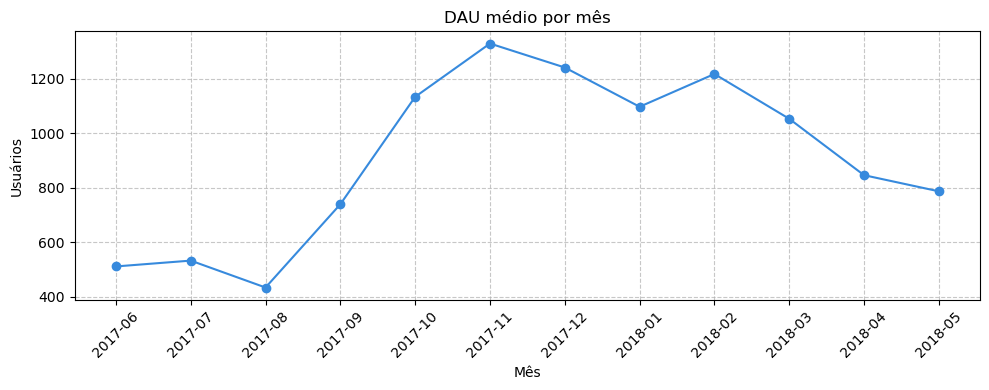

In [35]:
#Visualizando dau médio por mês
dau_monthly = (visits
  .groupby('month')
  .apply(lambda g: g.groupby('date')['uid'].nunique().mean())
  .reset_index())
dau_monthly.columns = ['month', 'dau']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dau_monthly['month'].astype('str'), 
        dau_monthly['dau'], marker='o', color='#378ADD')
ax.set_title('DAU médio por mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Usuários')
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

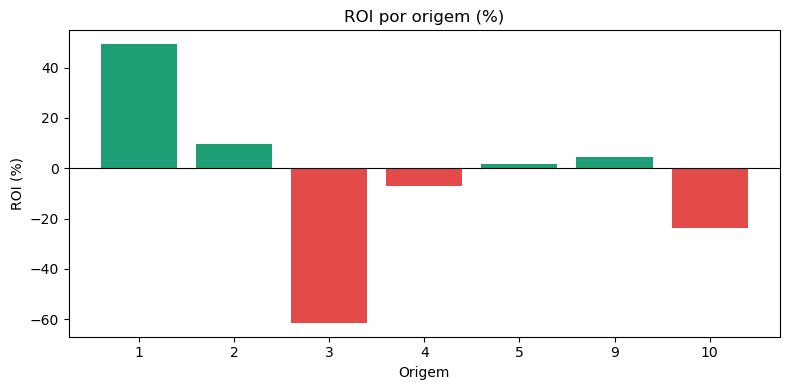

In [ ]:
#Visualizando o ROI por origem
roi_vals = summary['roi_pct']
cores = ['#1D9E75' if v >= 0 else '#E24B4A' for v in roi_vals]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(roi_vals.index.astype('str'), roi_vals, color=cores)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ROI por origem (%)')
ax.set_xlabel('Origem')
ax.set_ylabel('ROI (%)')
plt.tight_layout()
plt.show()

O investimento total em marketing foi de $329 mil, crescendo até dezembro de 2017 e caindo ao longo de 2018. A forte correlação entre investimento e usuários ativos mostra que o produto depende muito de mídia paga e possui pouca retorno orgânico.O ROI geral do período foi negativo, principalmente por causa da Origem 3, que recebeu 43% do orçamento, mas gerou um ROI de -61%, resultando em grande prejuízo. Por outro lado, a origem 1 apresentou o melhor desempenho, com ROI de +49,2% usando apenas 6,3% do orçamento. Já a Origem 9 teve o segundo menor CAC ($5,07) e também ROI positivo, mesmo recebendo apenas 1,7% do investimento. Com base nisso, a principal recomendação é reduzir ou renegociar os investimentos na origem 3 e direcionar mais verba para as origens 1 e 9, que apresentaram melhor custo-benefício.